# Base Optimization Project

```
Copyright © 2024, United States Government, as represented by the Administrator of the National Aeronautics and Space Administration. All rights reserved.

The “"Fault Model Design tools - fmdtools version 2"” software is licensed under the Apache License, Version 2.0 (the "License"); you may not use this file except in compliance with the License. You may obtain a copy of the License at http://www.apache.org/licenses/LICENSE-2.0. 

Unless required by applicable law or agreed to in writing, software distributed under the License is distributed on an "AS IS" BASIS, WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied. See the License for the specific language governing permissions and limitations under the License.
```

## Model Overview

In [1]:
from fmdtools.sim import propagate
from fmdtools.define.architecture.function import FunctionArchitectureGraph
from fmdtools_examples.airspacelib.wildfireresponse.environment import FireMap, FireEnvironment, FirePropagation, sim_properties
from fmdtools_examples.airspacelib.wildfireresponse.aircraft import FireAircraft
from fmdtools_examples.airspacelib.wildfireresponse.wildfiresim import WildfireSim, plot_combined_response_from, double_size_p
from fmdtools_examples.airspacelib.wildfireresponse.wildfiresim import BasePlacementProblem
from IPython.display import HTML
import inspect

### Fire Map/Propagation

`FireMap` defines the map that the fire propagates over. 

In [2]:
sim_properties

{'grass': {'color': 'lightgreen'},
 'forest': {'color': 'darkgreen'},
 'scrub': {'color': 'gold'},
 'burning': {'color': 'red', 'as_bool': True, 'alpha': 0.5},
 'base': {'color': 'black'},
 'to_burn': {'color': 'yellow', 'as_bool': True, 'alpha': 0.5},
 'extinguished': {'color': 'grey'}}

(<Figure size 500x500 with 1 Axes>, <Axes: xlabel='x', ylabel='y'>)

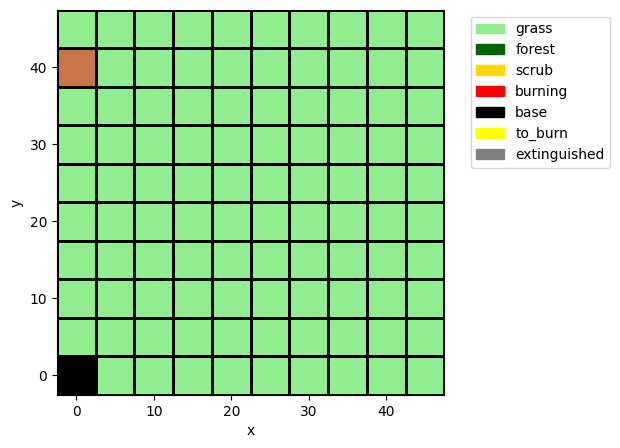

In [3]:
fm = FireMap()
fm

fm.show(sim_properties)


`FireMap` has a number of parameters that can be modified to simulate different types of fires:

In [4]:
fm.p
print(inspect.getsource(fm.p.__class__))

class FireMapParam(CoordsParam):
    """
    Parameter defining the fire map.

    Parameters
    ----------
    x_size: int
        Number of grid cells in the x. Default is 10.
    y_size: int
        Number of grid cells in the y. Default is 10.
    blocksize: float
        Size of grid cels. Default is 5.0, or 5 kilometers.
    base_locations: tuple
        Locations in the grid to put a base. Default is  ((0.0, 0.0),).
    num_strikes: int
        Number of strikes to initiate in the grid. Default is 1.
    map_type: str
        Type of map, specified as "uniform-xx","split-xx-yy", or "xx-yy-zz", where
        xx, yy, and zz are "grass", "forest", or "scrub" fuels
    grass_ig_time : float
        Grass cell ignition time. Default is 50.0 minutes
    grass_ex_time : float
        Grass cell extinguish time. Default is 90.0 minutes.
    scrub_ig_time : float
        Scrub cell ignition time. Default is 75.0 minutes
    scrub_ex_time : float
        Scrub cell extinguish time. Defau

The strike location is determined at the start of the simulation to be random based on the number of strikes.

We can chose between a few different types of firemaps as follows:

(<Figure size 500x500 with 1 Axes>, <Axes: xlabel='x', ylabel='y'>)

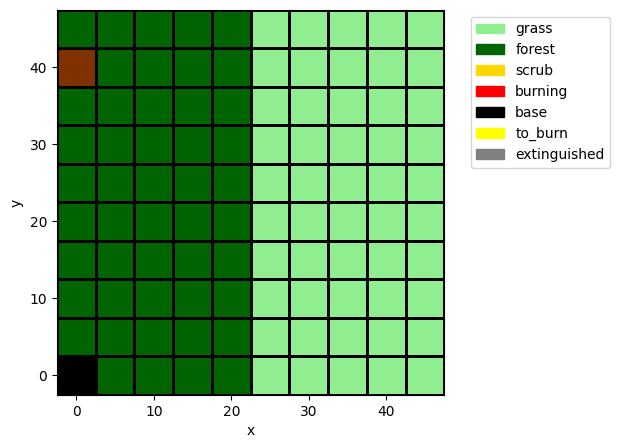

In [5]:
fm_bi = FireMap(p={'map_type': 'split-forest-grass'})
fm_bi.show(sim_properties)

(<Figure size 500x500 with 1 Axes>, <Axes: xlabel='x', ylabel='y'>)

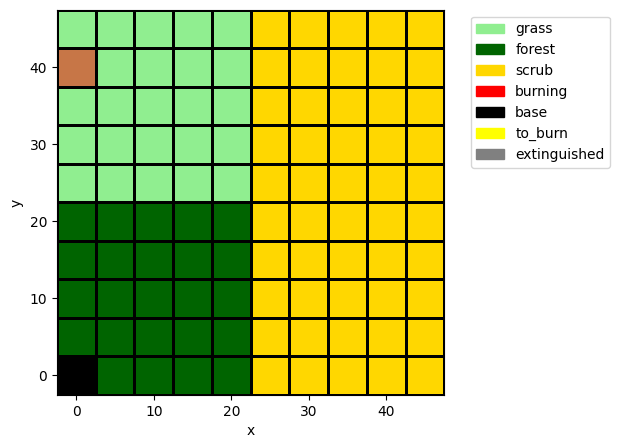

In [6]:
fm_tri = FireMap(p={'map_type': 'forest-grass-scrub'})
fm_tri.show(sim_properties)

we can also add base locations:

(<Figure size 500x500 with 1 Axes>, <Axes: xlabel='x', ylabel='y'>)

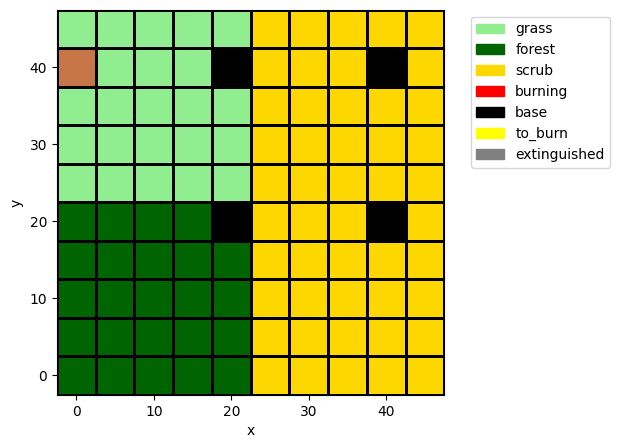

In [7]:
fm_bases = FireMap(p={'map_type': 'forest-grass-scrub', 'base_locations': ((20, 20),( 40, 40), (20, 40), (40, 20))})
fm_bases.show(sim_properties)

and add more or less strike locations:

(<Figure size 500x500 with 1 Axes>, <Axes: xlabel='x', ylabel='y'>)

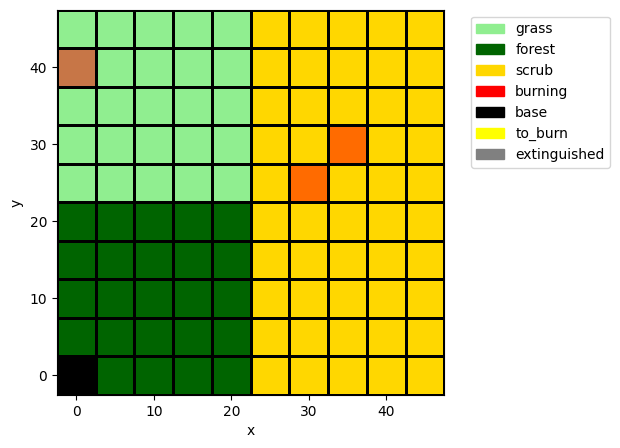

In [8]:
fm_three_strike = FireMap(p={'map_type': 'forest-grass-scrub', 'num_strikes': 3})
fm_three_strike.show(sim_properties)

Different samples can further be drawn by changing the random seed:

(<Figure size 500x500 with 1 Axes>, <Axes: xlabel='x', ylabel='y'>)

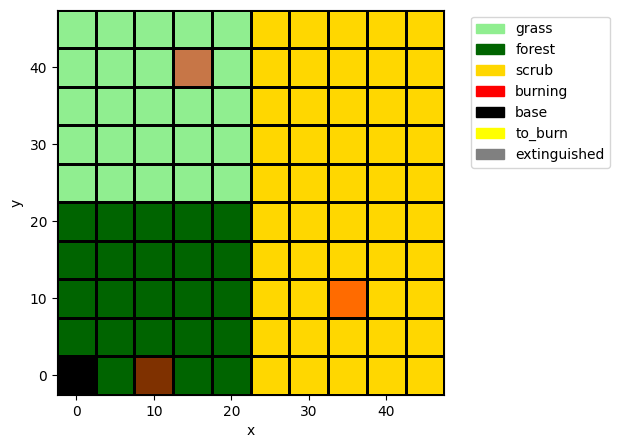

In [9]:
fm_three_strike = FireMap(p={'map_type': 'forest-grass-scrub', 'num_strikes': 3}, r={'seed': 250})
fm_three_strike.show(sim_properties)

Propagation of the fire is called from `FirePropagation`. 

In [10]:
fp = FirePropagation(track='all', fireenvironment=FireEnvironment(c={'p': {'map_type': 'forest-grass-scrub', 'num_strikes': 3}}))
fp

firepropagation FirePropagation
- t=Time(time=-0.1, timers={})
- s=FirePropagationState(perc_burned=0.0, leading_edge_length=0)
- fireenvironment=FireEnvironment(c=(), ga=())

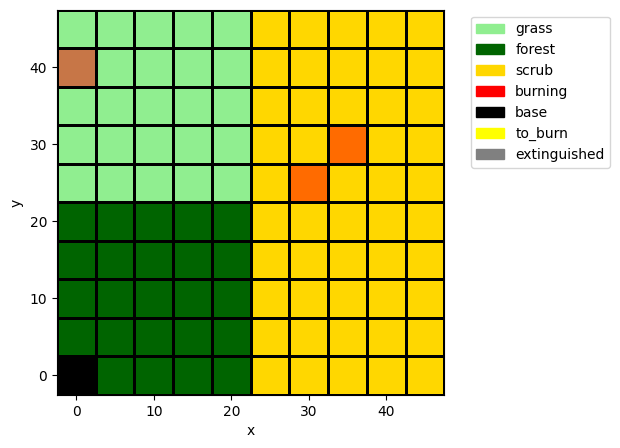

In [11]:
fig, ax = fp.fireenvironment.c.show(properties=sim_properties)

Below we simulate and visualize the propagation of the fire over time:

In [12]:
res, hist = propagate.nominal(fp, protect=False)

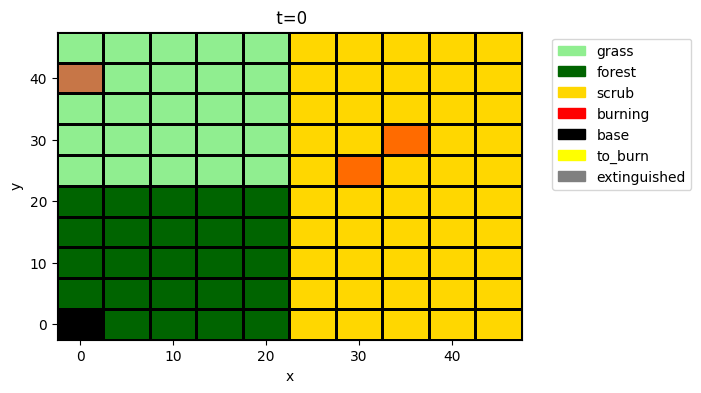

In [13]:
ani = fp.fireenvironment.c.animate(hist.fireenvironment.c, properties=sim_properties)
# HTML(ani.to_jshtml())

### Aircraft 

Aircraft fly from bases to mitigate the fire. They are defined in the `Aircraft` module.class

In [14]:
fe = FireEnvironment(c={"p": {"base_locations": ((40.0, 20.0),), "num_strikes": 3}})
fe.prop_time()
a1 = FireAircraft(s={'goal_x': 30, 'goal_y': 40}, fireenvironment=fe, track="all")

Below we simulate the aircraft responding to a (non-propagating) fire:

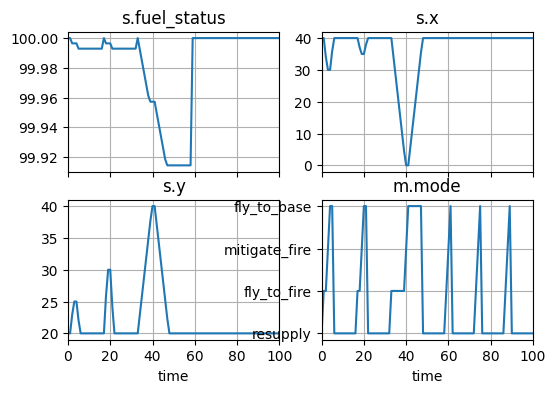

In [15]:
res, hist = propagate.nominal(a1, protect=False)
fig, ax = hist.plot_line('s.fuel_status', 's.x', 's.y', 'm.mode')

As shown above, the aircraft alternates between flying, mitigating, and resupplying, and resupply can take some time.

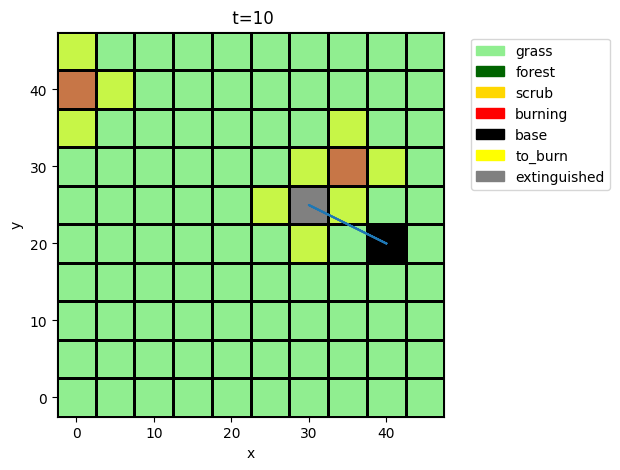

In [16]:
fig, ax = a1.fireenvironment.c.show_from(10, hist.fireenvironment.c, properties=sim_properties)
hist2 = hist.cut(10, newcopy=True)
hist2.plot_trajectory('s.x', 's.y', fig=fig, ax=ax)

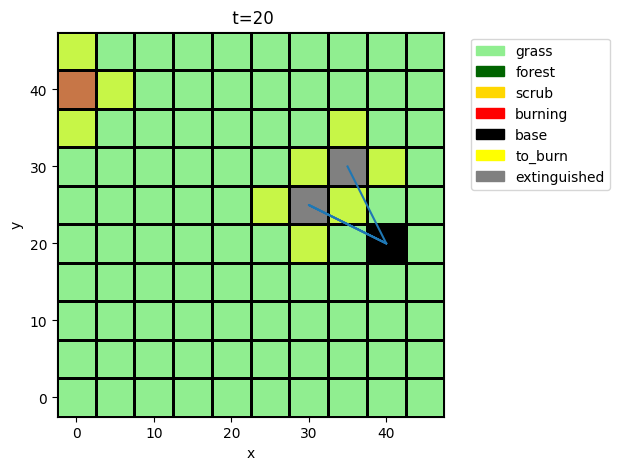

In [17]:
fig, ax = a1.fireenvironment.c.show_from(20, hist.fireenvironment.c, properties=sim_properties)
hist2 = hist.cut(20, newcopy=True)
hist2.plot_trajectory('s.x', 's.y', fig=fig, ax=ax)

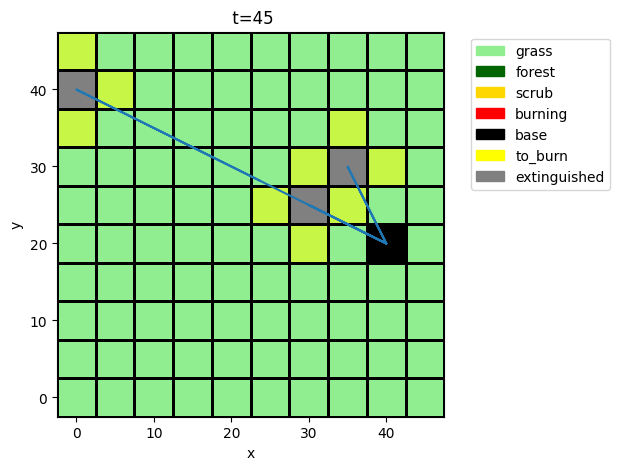

In [18]:
fig, ax = a1.fireenvironment.c.show_from(45, hist.fireenvironment.c, properties=sim_properties)
hist2 = hist.cut(45, newcopy=True)
hist2.plot_trajectory('s.x', 's.y', fig=fig, ax=ax)

### Combined Simulation

In [19]:
mdl = WildfireSim()

This integrated model has both firepropagation as well as aircraft. We can change the number of aircraft by changing the number of bases.

(<Figure size 1200x1000 with 1 Axes>, <Axes: >)

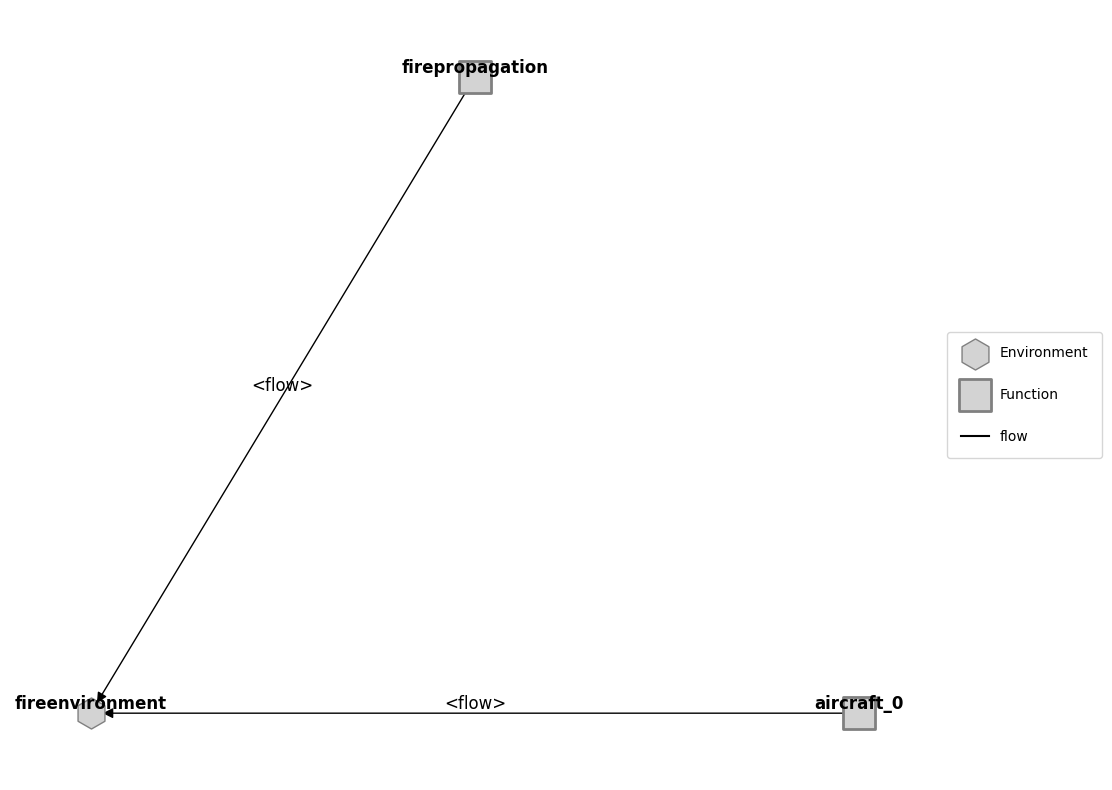

In [20]:
mdl_graph = FunctionArchitectureGraph(mdl)
mdl_graph.draw()

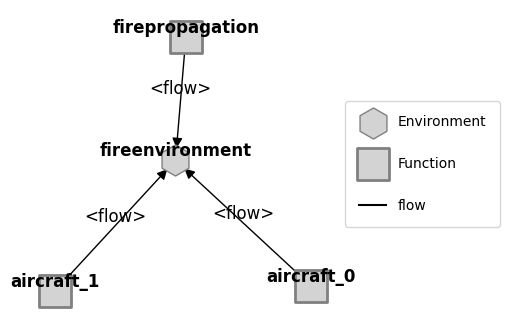

In [21]:
mdl2 = WildfireSim(p = {'firemapparam': {'base_locations': ((30, 30), (40, 40))}})
mdl2_graph = FunctionArchitectureGraph(mdl2)
mdl2_pos = {'wildfiresim.flows.fireenvironment': [-0.07, 0.05], 'wildfiresim.fxns.aircraft_0': [0.58, -0.62], 'wildfiresim.fxns.aircraft_1': [-0.65, -0.65], 'wildfiresim.fxns.firepropagation': [-0.02, 0.71]}
mdl2_graph.set_pos(**mdl2_pos)
fig, ax = mdl2_graph.draw(figsize=(4,4))
fig.savefig("response_structure.svg", bbox_inches='tight')

In [22]:
# %matplotlib qt5
# mdl2_graph.move_nodes()
# %matplotlib inline

Below we simulate the combined propagation and suppression of the fire

In [23]:
p = {'firemapparam': {**double_size_p, **{'num_strikes': 3, 'base_locations': ((0, 45),), 'map_type': 'forest-grass-scrub'}}}
mdl = WildfireSim(p = p)
res, hist = propagate.nominal(mdl, protect=False)

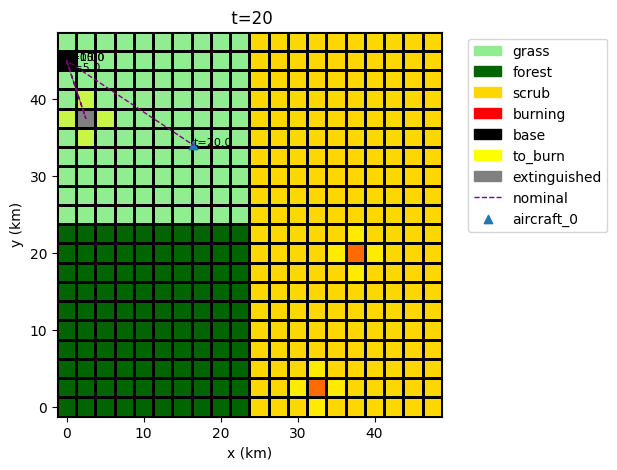

In [24]:
fig, ax = plot_combined_response_from(20, history=hist, mdl=mdl)

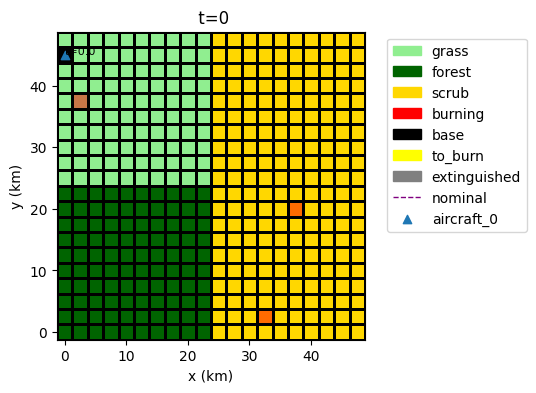

In [25]:
ani = hist.animate(plot_combined_response_from, mdl=mdl)
# HTML(ani.to_jshtml())

In [26]:
ani.save("single_aircraft_response.gif")

MovieWriter ffmpeg unavailable; using Pillow instead.


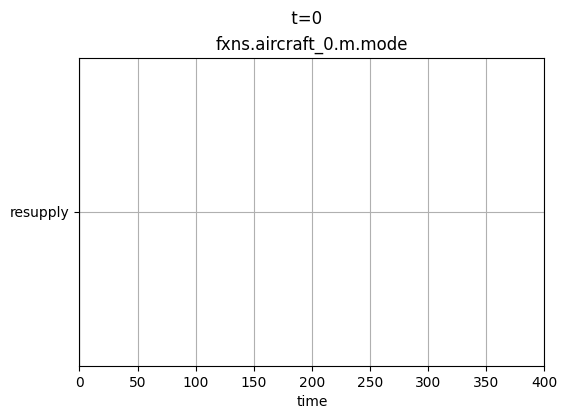

In [27]:
ani = hist.animate("plot_line_from",
                   plot_values=('fxns.aircraft_0.m.mode',),
                   legend_loc=False, t_line=True)
# HTML(ani.to_jshtml())

In [28]:
ani.save("single_aircraft_modes.gif")

MovieWriter ffmpeg unavailable; using Pillow instead.


<Figure size 640x480 with 0 Axes>

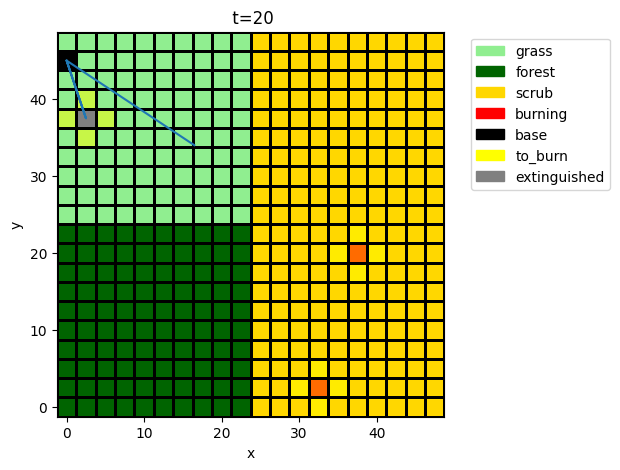

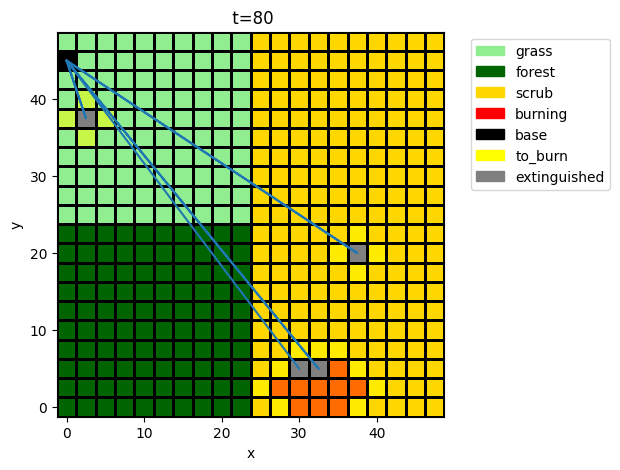

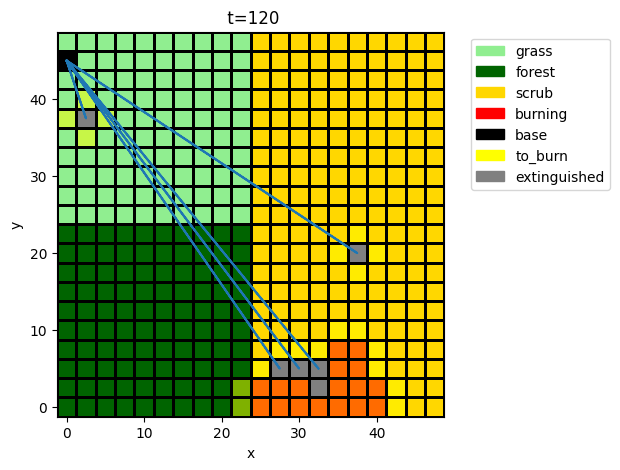

In [29]:
fig, ax = mdl.flows['fireenvironment'].c.show_from(20, hist.flows.fireenvironment.c,
                                                   properties=sim_properties)
hist20 = hist.cut(20, newcopy=True)
hist20.plot_trajectory('s.x', 's.y', fig=fig, ax=ax)

fig, ax = mdl.flows['fireenvironment'].c.show_from(80, hist.flows.fireenvironment.c,
                                                   properties=sim_properties)
hist20 = hist.cut(80, newcopy=True)
hist20.plot_trajectory('s.x', 's.y', fig=fig, ax=ax)

fig, ax = mdl.flows['fireenvironment'].c.show_from(120, hist.flows.fireenvironment.c,
                                                   properties=sim_properties)
hist20 = hist.cut(120, newcopy=True)
hist20.plot_trajectory('s.x', 's.y', fig=fig, ax=ax)

With two aircraft bases, the fire is put out more quickly:

In [30]:
p = {'firemapparam': {**double_size_p, **{'num_strikes': 3, 'base_locations': ((0, 45), (0, 0)), 'map_type': 'forest-grass-scrub'}}}
mdl = WildfireSim(p=p)
res, hist = propagate.nominal(mdl)

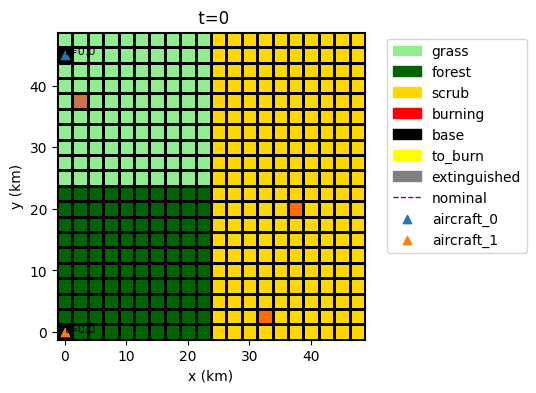

In [31]:
ani = hist.animate(plot_combined_response_from, mdl=mdl)
# HTML(ani.to_jshtml())

In [32]:
ani.save("multi_drone_response.gif")

MovieWriter ffmpeg unavailable; using Pillow instead.


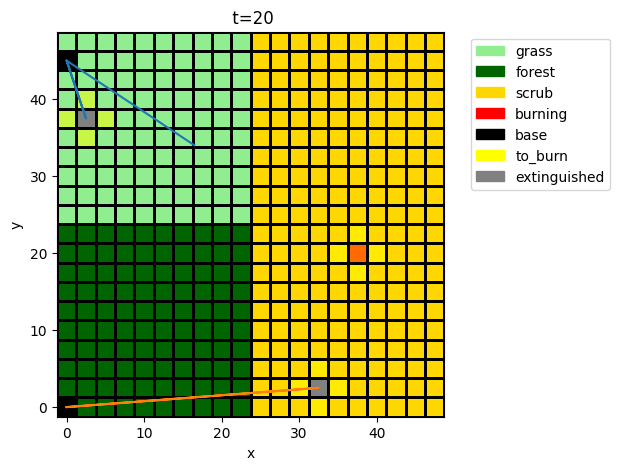

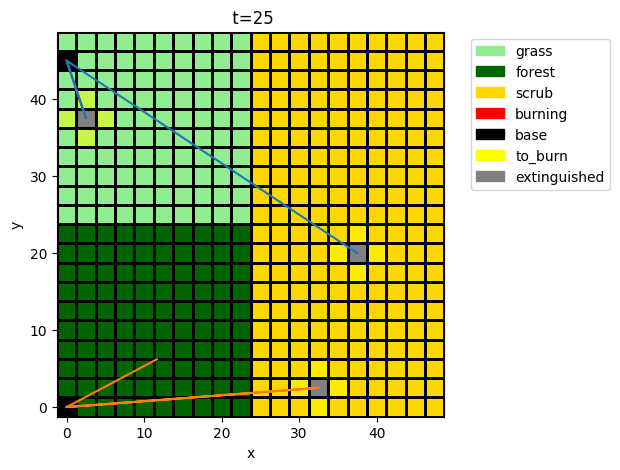

In [33]:
fig, ax = mdl.flows['fireenvironment'].c.show_from(20, hist.flows.fireenvironment.c,
                                                   properties=sim_properties)
hist20 = hist.cut(20, newcopy=True)
hist20.plot_trajectory('s.x', 's.y', fig=fig, ax=ax)

fig, ax = mdl.flows['fireenvironment'].c.show_from(25, hist.flows.fireenvironment.c,
                                                   properties=sim_properties)
hist80 = hist.cut(80, newcopy=True)
hist80.plot_trajectory('s.x', 's.y', fig=fig, ax=ax)

### Alternative Scenarios

In [34]:
p = {'firemapparam': {**double_size_p, **{'num_strikes': 3, 'base_locations': ((22.5, 22.5),), 'map_type': 'uniform-grass'}}}
mdl = WildfireSim(p = p)
res, hist = propagate.nominal(mdl)

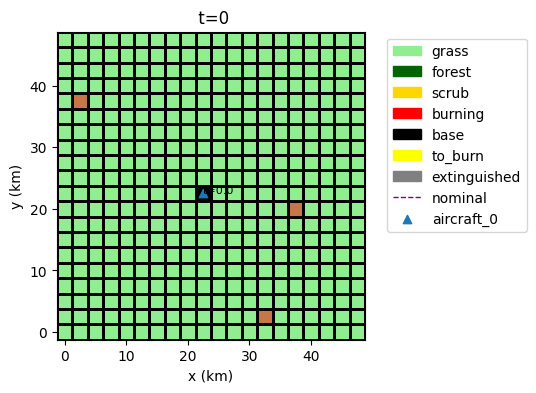

In [35]:
ani = hist.animate(plot_combined_response_from, mdl=mdl)
# HTML(ani.to_jshtml())

In [36]:
ani.save("three_strike_grass.gif")

MovieWriter ffmpeg unavailable; using Pillow instead.


In [37]:
p = {'firemapparam': {**double_size_p, **{'num_strikes': 3, 'base_locations': ((22.5, 22.5),), 'map_type': 'uniform-forest'}}}
mdl = WildfireSim(p = p)
res, hist = propagate.nominal(mdl)

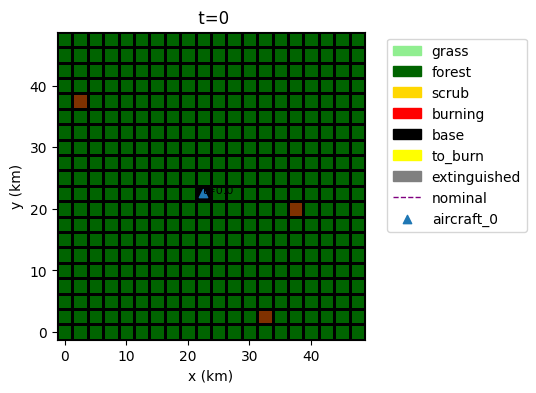

In [38]:
ani = hist.animate(plot_combined_response_from, mdl=mdl)
# HTML(ani.to_jshtml())

In [39]:
ani.save("three_strike_forest.gif")

MovieWriter ffmpeg unavailable; using Pillow instead.


#### Optimization

We can perform optimization by defining a problem to solve. Below the problem is to minimize burned area with a single base placement given random strikes.

In [40]:
psp = BasePlacementProblem(track='all', p={'firemapparam': {'num_strikes': 4}}, seed=1)
psp.perc_burned(10, 10)

np.float64(0.168)

In [41]:
psp

BasePlacementProblem with:
VARIABLES
 -x                                                         10.0000
 -y                                                         10.0000
OBJECTIVES
 -perc_burned                                                0.1680

The above number is the average percent burned over 10 random seeds. We can see the objective over all scenarios below:

In [42]:
psp.res

rep0_var_0.tend.classify.perc_burned: 0.09
rep0_var_0.tend.classify.burn_pts: array(10)
rep0_var_0.tend.fxns                0.09
rep1_var_1.tend.classify.perc_burned: 0.08
rep1_var_1.tend.classify.burn_pts: array(10)
rep1_var_1.tend.fxns                0.08
rep2_var_2.tend.classify.perc_burned: 0.2
rep2_var_2.tend.classify.burn_pts: array(10)
rep2_var_2.tend.fxns                 0.2
rep3_var_3.tend.classify.perc_burned: 0.14
rep3_var_3.tend.classify.burn_pts: array(10)
rep3_var_3.tend.fxns                0.14
rep4_var_4.tend.classify.perc_burned: 0.19
rep4_var_4.tend.classify.burn_pts: array(10)
rep4_var_4.tend.fxns                0.19
rep5_var_5.tend.classify.perc_burned: 0.24
rep5_var_5.tend.classify.burn_pts: array(10)
rep5_var_5.tend.fxns                0.24
rep6_var_6.tend.classify.perc_burned: 0.3
rep6_var_6.tend.classify.burn_pts: array(10)
rep6_var_6.tend.fxns                 0.3
rep7_var_7.tend.classify.perc_burned: 0.22
rep7_var_7.tend.classify.burn_pts: array(10)
rep7_var_7.

as well as evaluate the function over different base placements:

In [43]:
psp.perc_burned(40, 10)

np.float64(0.22500000000000003)

In [44]:
psp.perc_burned(40, 20)

np.float64(0.15700000000000003)

In [45]:
psp.perc_burned(20, 20)

np.float64(0.10400000000000001)

In [46]:
psp.res

rep0_var_0.tend.classify.perc_burned: 0.09
rep0_var_0.tend.classify.burn_pts: array(10)
rep0_var_0.tend.fxns                0.09
rep1_var_1.tend.classify.perc_burned: 0.06
rep1_var_1.tend.classify.burn_pts: array(10)
rep1_var_1.tend.fxns                0.06
rep2_var_2.tend.classify.perc_burned: 0.09
rep2_var_2.tend.classify.burn_pts: array(10)
rep2_var_2.tend.fxns                0.09
rep3_var_3.tend.classify.perc_burned: 0.13
rep3_var_3.tend.classify.burn_pts: array(10)
rep3_var_3.tend.fxns                0.13
rep4_var_4.tend.classify.perc_burned: 0.08
rep4_var_4.tend.classify.burn_pts: array(10)
rep4_var_4.tend.fxns                0.08
rep5_var_5.tend.classify.perc_burned: 0.23
rep5_var_5.tend.classify.burn_pts: array(10)
rep5_var_5.tend.fxns                0.23
rep6_var_6.tend.classify.perc_burned: 0.12
rep6_var_6.tend.classify.burn_pts: array(10)
rep6_var_6.tend.fxns                0.12
rep7_var_7.tend.classify.perc_burned: 0.07
rep7_var_7.tend.classify.burn_pts: array(10)
rep7_var_

In [47]:
psp.parameterdomain(10, 10)

WildFireSimParameter(firemapparam=FireMapParam(x_size=10, y_size=10, blocksize=5.0, gapwidth=0.0))

In [48]:
psp.sim_mdl

<bound method ParameterSimProblem.sim_mdl of BasePlacementProblem with:
VARIABLES
 -x                                                         20.0000
 -y                                                         20.0000
OBJECTIVES
 -perc_burned                                                0.1040>

(<Figure size 500x500 with 1 Axes>,
 <Axes: title={'center': ' t=10'}, xlabel='x', ylabel='y'>)

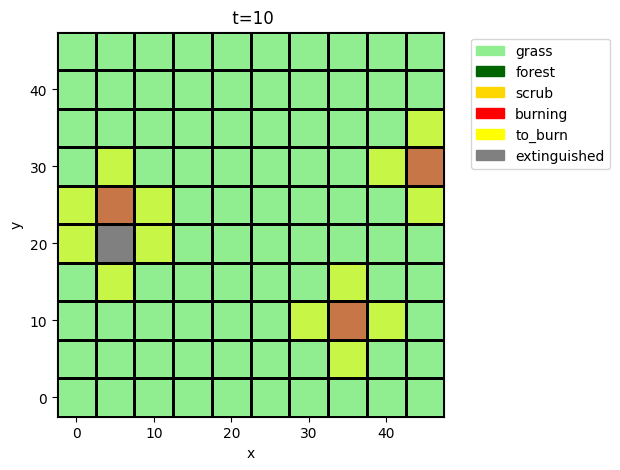

In [49]:
show_properties = {k:v for k,v in sim_properties.items() if k!="base"}
psp.mdl.flows['fireenvironment'].c.show_from(10, psp.hist.rep0_var_0.flows.fireenvironment.c, show_properties)

In [50]:
psp.hist.rep0_var_0.flows.fireenvironment.c.burning[0].shape

(10, 10)

(<Figure size 500x500 with 1 Axes>,
 <Axes: title={'center': ' t=35'}, xlabel='x', ylabel='y'>)

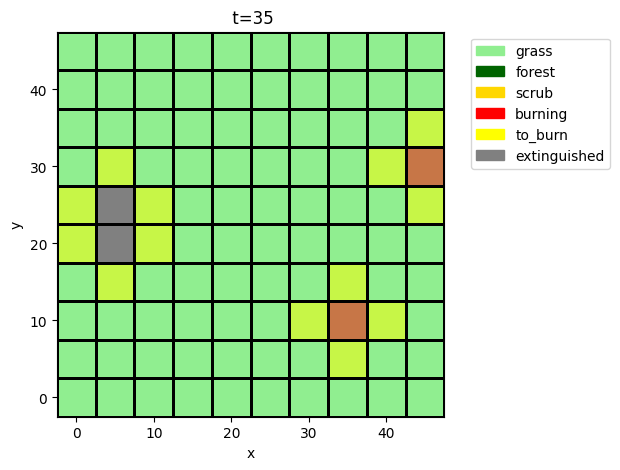

In [51]:
psp.mdl.flows['fireenvironment'].c.show_from(35, psp.hist.rep0_var_0.flows.fireenvironment.c, show_properties)